# Colab setup (run this first on Google Colab)

If you're on **Google Colab**:
1. **Runtime → Change runtime type → GPU** (T4 is enough for Gemma 270M/1B, A100 needed for larger models).
2. Run the cell below to clone the repo (edit the `git clone` URL if needed) or, if you uploaded the project, run `%cd /content/multilingual-agreement` and `!pip install -e . -q` so the project root is correct.
3. Then run the rest of the notebook.

NB: **Hugging Face**: Gemma is gated. Use the login cell with your own token (in this case, taken from Colab Secrets).

In [1]:
# Run this cell only on Google Colab to clone the repo and install the project (private repo: needs a PAT).
import os
import subprocess
import sys
from pathlib import Path
from urllib.parse import quote

REPO_DIR = Path("/content/multilingual-agreement")
REPO_SSH_PATH = "smilni/multilingual-agreement.git"

if "google.colab" in sys.modules:
    import getpass

    token = None
    try:
        from google.colab import userdata

        token = userdata.get("GITHUB_TOKEN")
    except Exception:
        pass
    if not (token and str(token).strip()):
        token = getpass.getpass("GitHub PAT (read access to repo), or set Colab secret GITHUB_TOKEN: ")

    token = str(token).strip()
    authed_url = f"https://x-access-token:{quote(token, safe='')}@github.com/{REPO_SSH_PATH}"

    if REPO_DIR.is_dir() and (REPO_DIR / ".git").is_dir():
        subprocess.run(
            ["git", "-C", str(REPO_DIR), "pull", "--ff-only"],
            check=True,
            env={**os.environ, "GIT_TERMINAL_PROMPT": "0"},
        )
    else:
        subprocess.run(
            ["git", "clone", authed_url, str(REPO_DIR)],
            check=True,
            cwd="/content",
        )

    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-e", ".", "-q"], check=True)
else:
    print("Not on Colab; skipping clone/install.")

# Sanity Check: Model Competence on MultiBLiMP

Before running any mechanistic analysis, we verify that the model reliably
distinguishes grammatical from ungrammatical verb forms in subject-verb
number agreement constructions.

**What this notebook does:**
1. Downloads and inspects MultiBLiMP data for English, German, and Spanish
2. Filters to subject-verb number agreement pairs
3. Loads a Gemma 3 pretrained model
4. Computes the log-probability gap between grammatical and ungrammatical continuations
5. Reports per-language accuracy

In [16]:
from google.colab import userdata
from huggingface_hub import login
HF_TOKEN = userdata.get("HF_TOKEN")
login(token=HF_TOKEN)

In [17]:
import sys
from pathlib import Path

# Works locally (cwd = notebooks/) and on Colab (cwd = repo root after clone)
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import load_config
from src.data.multiblimp import (
    load_all_languages,
    pairs_to_dataframe,
)
from src.model.loading import load_model
from src.evaluation.competence import (
    evaluate_all, summarize_results, results_to_records,
    load_number_pairs, evaluate_all_number_pairs, summarize_number_pair_results,
)
from src.utils.logging import save_results

cfg = load_config()

##  A. Original MultiBLiMP evaluations

### 0. Define necessary functions

In [18]:
def run_evaluation(model, tokenizer, all_pairs, device, scoring, debug=False):
    results_by_lang = {}
    summaries = {}
    for lang_code, pairs in all_pairs.items():
        if not pairs:
            continue
        results = evaluate_all(model, tokenizer, pairs, device=device, scoring=scoring, debug=debug)
        results_by_lang[lang_code] = results
        summaries[lang_code] = summarize_results(results)
    return results_by_lang, summaries


def print_summary_table(summaries, min_accuracy=0.8):
    print("\n" + "=" * 55)
    print(f"{'Lang':<6} {'Accuracy':>10} {'Mean Gap':>10} {'N':>6} {'Pass':>8}")
    print("-" * 55)
    for lang_code, s in summaries.items():
        passed = "YES" if s["accuracy"] >= min_accuracy else "NO"
        print(f"{lang_code:<6} {s['accuracy']:>10.3f} {s['mean_logprob_gap']:>10.4f} {s['n']:>6d} {passed:>8}")
    print("=" * 55)


def plot_competence_overview(summaries, results_by_lang, lang_names, model_key, mode, project_root, min_accuracy=0.8, show=False):
    n_langs = len(summaries)
    out_dir = project_root / "results" / "figures" / model_key
    out_dir.mkdir(parents=True, exist_ok=True)

    # Figure 1: accuracy bar chart
    fig_bar = plt.figure(figsize=(max(5, 2 * n_langs), 4))
    acc_df = pd.DataFrame([
        {"Language": lang_names[lc], "Accuracy": s["accuracy"]} for lc, s in summaries.items()
    ])
    sns.barplot(data=acc_df, x="Language", y="Accuracy")
    ax = plt.gca()
    ax.yaxis.grid(True, linestyle="-", alpha=0.4)
    ax.set_axisbelow(True)
    plt.axhline(0.5, ls="--", color="gray", label="Random (50%)")
    plt.ylim(0, 1.05)
    plt.title(f"{model_key}; agreement accuracy by language")
    plt.tight_layout()
    path_bar = out_dir / f"competence_accuracy_{mode}.png"
    plt.savefig(path_bar, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig_bar)

    # Figure 2: log-prob gap distributions (label + facets)
    fig_gaps = plt.figure(figsize=(4 * n_langs, 5))
    gs = fig_gaps.add_gridspec(2, n_langs, height_ratios=[0.12, 1], hspace=0.3)
    ax_label = fig_gaps.add_subplot(gs[0, :])
    ax_label.axis("off")
    ax_label.text(0.5, 0.5, f"{model_key}; log-prob gap by language", ha="center", va="center", fontsize=11)
    all_gaps = [r.logprob_gap for results in results_by_lang.values() for r in results]
    gap_min, gap_max = min(all_gaps), max(all_gaps)
    margin = (gap_max - gap_min) * 0.05 or 0.5
    xlim = (gap_min - margin, gap_max + margin)
    for i, (lang_code, results) in enumerate(results_by_lang.items()):
        ax = fig_gaps.add_subplot(gs[1, i])
        df = pd.DataFrame({
            "gap": [r.logprob_gap for r in results],
            "correct": [r.correct for r in results],
        })
        df["correct"] = df["correct"].map({True: "Correct", False: "Incorrect"})
        sns.histplot(data=df, x="gap", hue="correct", ax=ax, stat="probability", common_norm=True, bins=40)
        ax.axvline(0, ls="--", color="black", lw=0.8)
        ax.set_xlim(xlim)
        ax.set_title(lang_names[lang_code])
        ax.set_xlabel("Log-prob gap (good − bad)")
        ax.set_ylabel("Proportion" if i == 0 else "")
    plt.tight_layout()
    path_gaps = out_dir / f"competence_gaps_{mode}.png"
    plt.savefig(path_gaps, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig_gaps)
    return path_bar, path_gaps


def save_competence_results(results_by_lang, summaries, model_key, mode, model_cfg):
    subdir = f"competence/{model_key}"
    out_dir = PROJECT_ROOT / "results" / "competence" / model_key
    out_dir.mkdir(parents=True, exist_ok=True)
    paths = []
    for lang_code, results in results_by_lang.items():
        path = save_results(
            {"summary": summaries[lang_code], "pairs": results_to_records(results)},
            filename=f"competence_{mode}_{lang_code}",
            subdir=subdir,
        )
        paths.append((lang_code, path))
    summary_path = save_results(
        {"model": model_key, "model_hf_id": model_cfg.hf_id, "summaries": summaries, "mode": mode},
        filename=f"competence_{mode}_summary",
        subdir=subdir,
    )
    return paths, summary_path

### 1. Load data

In [19]:
all_pairs = load_all_languages(filter_agreement=True, svo_only=True)

for lang_code, pairs in all_pairs.items():
    print(f"\n{'='*60}")
    print(f" {lang_code}: {len(pairs)} SV pairs (subject before verb)")
    print(f"{'='*60}")
    for p in pairs[:2]:
        print(f"  GOOD: {p.good_sentence[:90]}")
        print(f"  prefix='{p.prefix[:60]}'")
        print(f"  child_idx={p.child_idx}  verb_idx={p.verb_idx}")
        print()

2026-04-19 14:03:35,773 | src.data.multiblimp | INFO | Using cached MultiBLiMP data for eng


INFO:src.data.multiblimp:Using cached MultiBLiMP data for eng


2026-04-19 14:03:35,791 | src.data.multiblimp | INFO | Filtered 770 -> 317 number-agreement pairs (lang=eng)


INFO:src.data.multiblimp:Filtered 770 -> 317 number-agreement pairs (lang=eng)


2026-04-19 14:03:35,793 | src.data.multiblimp | INFO | SVO filter: 317 -> 300 pairs (lang=eng)


...

2026-04-19 14:03:35,990 | src.data.multiblimp | INFO | SVO filter: 800 -> 400 pairs (lang=spa)


INFO:src.data.multiblimp:SVO filter: 800 -> 400 pairs (lang=spa)


2026-04-19 14:03:36,030 | src.data.multiblimp | INFO | Loaded 400 minimal pairs for spa


INFO:src.data.multiblimp:Loaded 400 minimal pairs for spa



 eng: 300 SV pairs (subject before verb)
  GOOD: The below site from the US government verifies this-it 's the same for Canada ,too.....
  prefix='The below site from the US government'
  child_idx=2  verb_idx=7

  GOOD: Typically, a developer creates an XSL transformation file that, when applied to an XML doc
  prefix='Typically, a developer creates an XSL transformation file th'
  child_idx=9  verb_idx=20


 deu: 400 SV pairs (subject before verb)
  GOOD: Die Grafschaft, die sich zwischen Rabnitzbach und Raab erstreckte, dürfte bereits um 844 b
  prefix='Die Grafschaft, die sich zwischen Rabnitzbach und Raab erstr'
  child_idx=1  verb_idx=15

  GOOD: Wer in einer angenehmen Atmosphäre und bei Sonne segeln oder segeln lernen möchte, der ist
  prefix='Wer in einer angenehmen Atmosphäre und bei Sonne segeln oder'
  child_idx=0  verb_idx=8


 spa: 400 SV pairs (subject before verb)
  GOOD: Kohl interpretó en su favor el hecho de que el encargado de analizar la desaparición de es
  prefi

In [20]:
dfs = {code: pairs_to_dataframe(pairs) for code, pairs in all_pairs.items() if pairs}
overview = pd.DataFrame([
    {"language": code, "n_pairs": len(df)}
    for code, df in dfs.items()
])
overview

,language,n_pairs
0,eng,300
1,deu,400
2,spa,400


In [21]:
dfs['eng'].head(2)

,uid,good_sentence,bad_sentence,prefix,good_continuation,bad_continuation,language,paradigm,field,good_verb,bad_verb,word_order,child_idx,verb_idx,has_attractor,distance
0,SV-#,The below site from the US government verifies...,The below site from the US government verify t...,The below site from the US government,"verifies this-it 's the same for Canada ,too.....","verify this-it 's the same for Canada ,too.....",eng,SV-#,SG vs PL,verifies,verify,SV,2,7,True,5
1,SV-#,"Typically, a developer creates an XSL transfor...","Typically, a developer creates an XSL transfor...","Typically, a developer creates an XSL transfor...",interprets or transforms the XML data into a p...,interpret or transforms the XML data into a pr...,eng,SV-#,SG vs PL,interprets,interpret,SV,9,20,True,11


### 2. Load the model

Show example processing with the smallest model (`'gemma-3-270m'`).

In [22]:
# Optional: load one model for spot-checks. The "Run all" cell (§5) uses MODELS_TO_RUN and does not depend on this.
MODEL_KEY = "gemma-3-270m"  # change to "gemma-3-1b" if needed
# Single GPU: set MULTI_GPU = False and GPU_ID = 0, 1, 2, ...
# Multiple GPUs: set MULTI_GPU = True (model is spread across visible GPUs).
#   To use specific GPUs only, set CUDA_VISIBLE_DEVICES in the first cell before importing torch, e.g.:
#   import os; os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
MULTI_GPU = False
GPU_ID = 0

model_cfg = cfg.models[MODEL_KEY]

if torch.cuda.is_available():
    device_str = "auto" if MULTI_GPU else f"cuda:{GPU_ID}"

model, tokenizer = load_model(model_cfg, device=device_str)
device = next(model.parameters()).device
print(f"Model loaded: {model_cfg.hf_id} on {device}")

2026-04-19 14:03:36,444 | src.model.loading | INFO | Loading model google/gemma-3-270m ...


INFO:src.model.loading:Loading model google/gemma-3-270m ...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

2026-04-19 14:03:40,559 | src.model.loading | INFO | Model loaded on cuda:0


INFO:src.model.loading:Model loaded on cuda:0


Model loaded: google/gemma-3-270m on cuda:0


### 3. Quick check on a few examples

Before running the full evaluation, let's take a look at some predictions.

In [23]:
from src.evaluation.competence import evaluate_pair

# Pick a few pairs from the first available language
spot_lang = [code for code, pairs in all_pairs.items() if pairs][0]
spot_pairs = all_pairs[spot_lang][:5]

print(f"Spot-check on {spot_lang} ({len(spot_pairs)} pairs):\n")
for p in spot_pairs:
    r = evaluate_pair(model, tokenizer, p, device, scoring="full_sentence")
    mark = "OK" if r.correct else "WRONG"
    print(f"[{mark}] gap={r.logprob_gap:+.4f}")
    print(f"  prefix: '{r.prefix}'")
    print(f"  good ({r.good_logprob:.4f}): '{r.good_continuation}'")
    print(f"  bad  ({r.bad_logprob:.4f}): '{r.bad_continuation}'")
    print()

Spot-check on eng (5 pairs):

[OK] gap=+2.5850
  prefix: 'The below site from the US government'
  good (-110.5488): 'verifies this-it 's the same for Canada ,too.....'
  bad  (-113.1338): 'verify this-it 's the same for Canada ,too.....'

[OK] gap=+10.7921
  prefix: 'Typically, a developer creates an XSL transformation file that, when applied to an XML document during export,'
  good (-196.9559): 'interprets or transforms the XML data into a presentation format that can be recognized by another application, such as Service Advertising Protocol (SAP) or a custom purchase order format.'
  bad  (-207.7480): 'interpret or transforms the XML data into a presentation format that can be recognized by another application, such as Service Advertising Protocol (SAP) or a custom purchase order format.'

[OK] gap=+3.7974
  prefix: 'In the best case, the clamoring for a "refund"'
  good (-71.3291): 'subsides.'
  bad  (-75.1265): 'subside.'

[OK] gap=+3.1172
  prefix: 'Can you accept that the road 

### 4. Full competence evaluation

Example run. Run `gemma-3-270m` on all SV number-agreement pairs for each language in `first-diverging-token` evaluation setting.

In [24]:
lang_names = {lc: next(l.name for l in cfg.languages if l.code == lc) for lc in list(all_pairs.keys())}
min_acc = getattr(cfg, "competence_min_accuracy", 0.8)

results_by_lang, summaries = run_evaluation(model, tokenizer, all_pairs, device, scoring="first_token", debug=False)
print_summary_table(summaries, min_accuracy=0.8)

Evaluating competence: 100%|██████████| 400/400 [00:15<00:00, 25.01it/s]


Lang     Accuracy   Mean Gap      N     Pass
-------------------------------------------------------
eng         0.943     4.4309    300      YES
deu         0.865     2.7677    400      YES
spa         0.900     3.4143    400      YES


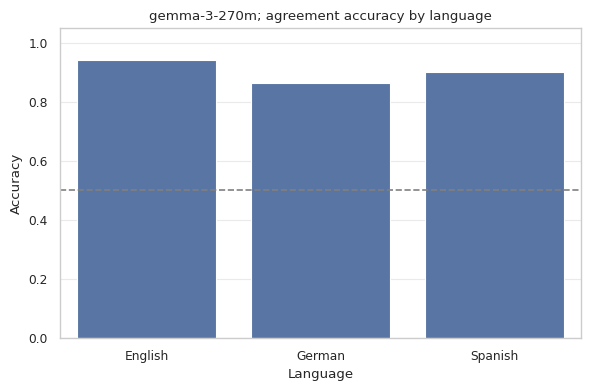

/tmp/ipykernel_14402/3803557402.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


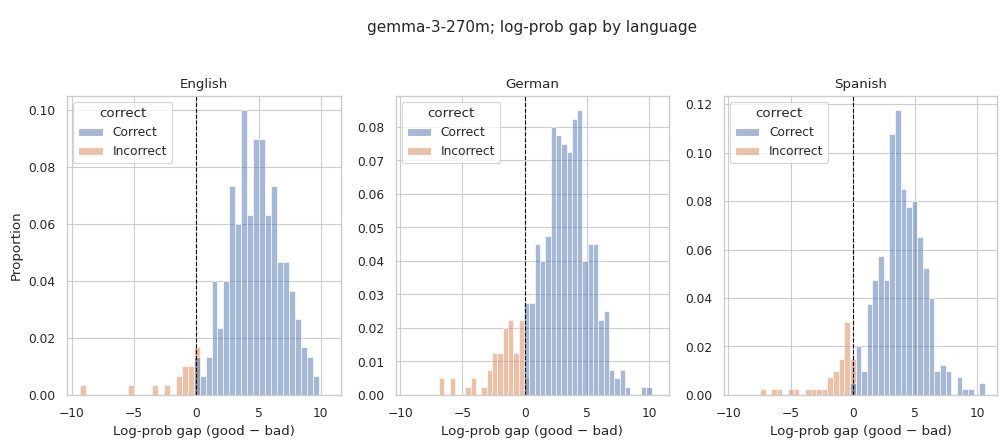

(PosixPath('/content/multilingual-agreement/results/figures/gemma-3-270m/competence_accuracy_first_token.png'),
 PosixPath('/content/multilingual-agreement/results/figures/gemma-3-270m/competence_gaps_first_token.png'))

In [25]:
plot_competence_overview(summaries, results_by_lang, lang_names, MODEL_KEY, "first_token", PROJECT_ROOT, min_accuracy=0.8, show=True)

### 5. Error analysis

In [26]:
for lang_code, results in results_by_lang.items():
    errors = [r for r in results if not r.correct]
    print(f"\n{'='*60}")
    print(f" {lang_names[lang_code]} — {len(errors)} errors out of {len(results)}")
    print(f"{'='*60}")
    for r in errors[:10]:
        print(f"  gap={r.logprob_gap:+.4f}  prefix='{r.prefix}'")
        print(f"    good ({r.good_logprob:.3f}): '{r.good_continuation}'")
        print(f"    bad  ({r.bad_logprob:.3f}): '{r.bad_continuation}'")
        print()


 English — 17 errors out of 300
  gap=-3.2500  prefix='Scientific research to develop products like irradiated sterile insects or the Oxitec mosquitoes'
    good (-17.000): 'proceeds progressively from more to less contained conditions – from the laboratory to confined trials to limited field trials.'
    bad  (-13.750): 'proceed progressively from more to less contained conditions – from the laboratory to confined trials to limited field trials.'

  gap=-1.5000  prefix='Perhaps that 's why a surge of tears'
    good (-10.312): 'clouds his pupils while the syllable of time unearths his crop and surrenders his mystery to the bound waters.'
    bad  (-8.812): 'cloud his pupils while the syllable of time unearths his crop and surrenders his mystery to the bound waters.'

  gap=-0.3125  prefix='I really like the MIUI, but a process'
    good (-10.000): 'crashes repeatedly about every 3 seconds.'
    bad  (-9.688): 'crash repeatedly about every 3 seconds.'

  gap=-0.5625  prefix='Someone'


In [27]:
save_competence_results(results_by_lang, summaries, MODEL_KEY, "first_token", model_cfg)

([('eng',
   PosixPath('/content/multilingual-agreement/results/competence/gemma-3-270m/competence_first_token_eng_20260419_140426.json')),
  ('deu',
   PosixPath('/content/multilingual-agreement/results/competence/gemma-3-270m/competence_first_token_deu_20260419_140426.json')),
  ('spa',
   PosixPath('/content/multilingual-agreement/results/competence/gemma-3-270m/competence_first_token_spa_20260419_140426.json'))],
 PosixPath('/content/multilingual-agreement/results/competence/gemma-3-270m/competence_first_token_summary_20260419_140426.json'))

### 6. Large-scale MultiBLiMP run (all models, scoring = first diverging token)

In [17]:
MODELS_TO_RUN = ['gemma-3-270m', 'gemma-3-1b', 'gemma-3-4b', 'gemma-3-12b']
SCORING_MODES = ["first_token"]
MULTI_GPU = False
GPU_ID = 0

if torch.cuda.is_available():
    device_str = "auto" if MULTI_GPU else f"cuda:{GPU_ID}"

lang_names = {lc: next(l.name for l in cfg.languages if l.code == lc) for lc in list(all_pairs.keys())}
min_acc = getattr(cfg, "competence_min_accuracy", 0.8)

for model_key in MODELS_TO_RUN:
    model_cfg = cfg.models[model_key]
    print(f"\n{'#'*60}\n# Model: {model_key}\n{'#'*60}")
    model, tokenizer = load_model(model_cfg, device=device_str)
    device = next(model.parameters()).device
    for mode in SCORING_MODES:
        print(f"\n--- Scoring: {mode} ---")
        results_by_lang, summaries = run_evaluation(model, tokenizer, all_pairs, device, mode)
        plot_competence_overview(summaries, results_by_lang, lang_names, model_key, mode, PROJECT_ROOT, min_acc)
        save_competence_results(results_by_lang, summaries, model_key, mode, model_cfg)
        MODEL_KEY, MODE = model_key, mode
    del model, tokenizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


############################################################
# Model: gemma-3-270m
############################################################
2026-04-19 12:57:19,429 | src.model.loading | INFO | Loading model google/gemma-3-270m ...


INFO:src.model.loading:Loading model google/gemma-3-270m ...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

2026-04-19 12:57:23,625 | src.model.loading | INFO | Model loaded on cuda:0


INFO:src.model.loading:Model loaded on cuda:0


...

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

2026-04-19 13:02:51,344 | src.model.loading | INFO | Model loaded on cuda:0


INFO:src.model.loading:Model loaded on cuda:0



--- Scoring: first_token ---


Evaluating competence: 100%|██████████| 400/400 [00:41<00:00,  9.58it/s]
/tmp/ipykernel_5272/3803557402.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


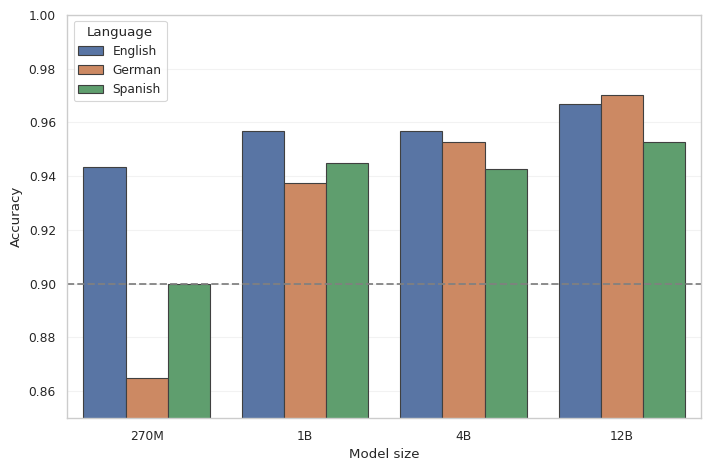

Saved: /content/multilingual-agreement/results/figures/competence_accuracy_all_models_first_token_barplot.png


In [29]:
SCORING_MODES = ["first_token"]
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
import json
import re
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

competence_dir = PROJECT_ROOT / "results" / "competence"
out_dir = PROJECT_ROOT / "results" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="paper")
palette = ["#4C72B0", "#DD8452", "#55A868"]

summary_paths = sorted(competence_dir.glob("*/competence_*_summary_*.json"))
pat = re.compile(r"^competence_(.+)_summary_(\d{8})_(\d{6})$")

rows = []
for p in summary_paths:
    m = pat.match(p.stem)
    if not m:
        continue
    setting, d, t = m.groups()
    if setting == "number_pairs":
        continue
    timestamp = f"{d}_{t}"
    payload = json.loads(p.read_text())
    model = payload.get("model", p.parent.name)

    for lang, metrics in payload.get("summaries", {}).items():
        rows.append(
            {
                "model": model,
                "setting": setting,
                "language": lang,
                "accuracy": metrics["accuracy"],
                "n": metrics["n"],
                "n_correct": metrics["n_correct"],
                "mean_logprob_gap": metrics["mean_logprob_gap"],
                "timestamp": timestamp,
            }
        )

all_df = pd.DataFrame(rows)
if all_df.empty:
    raise ValueError(f"No competence summary files found in {competence_dir}")

latest_df = (
    all_df.sort_values("timestamp")
    .groupby(["model", "setting", "language"], as_index=False)
    .tail(1)
    .copy()
)

model_order = ["gemma-3-270m", "gemma-3-1b", "gemma-3-4b", "gemma-3-12b"]
model_labels = {
    "gemma-3-270m": "270M",
    "gemma-3-1b": "1B",
    "gemma-3-4b": "4B",
    "gemma-3-12b": "12B",
}
lang_order = ["eng", "deu", "spa"]
lang_names = {"eng": "English", "deu": "German", "spa": "Spanish"}

latest_df["model"] = pd.Categorical(latest_df["model"], categories=model_order, ordered=True)
latest_df["language"] = pd.Categorical(latest_df["language"], categories=lang_order, ordered=True)
latest_df = latest_df.sort_values(["setting", "model", "language"]).copy()

latest_df["Model size"] = latest_df["model"].map(model_labels)
latest_df["Language"] = latest_df["language"].map(lang_names)

sns.set_theme(style="whitegrid", context="paper")

for setting in SCORING_MODES:
    plot_df = latest_df[latest_df["setting"] == setting].copy()
    if plot_df.empty:
        continue

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    sns.barplot(
        data=plot_df,
        x="Model size",
        y="accuracy",
        hue="Language",
        hue_order=["English", "German", "Spanish"],
        ax=ax,
        edgecolor="0.25",
        linewidth=0.8,
        palette=palette,
    )

    ax.axhline(0.9, linestyle="--", linewidth=1.4, color="gray", alpha=0.9)

    if setting == "verb":
        ax.set_title("Verb-conditioned agreement accuracy by model size", fontsize=13, pad=10)
    elif setting == "full-sentence":
        ax.set_title("Full-sentence agreement accuracy by model size", fontsize=13, pad=10)
    elif setting == "first-diverging-token":
        ax.set_title("First-diverging-token agreement accuracy by model size", fontsize=13, pad=10)

    ax.set_xlabel("Model size")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.85, 1.0)

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    legend = ax.legend(
        title="Language",
        loc="upper left",
        frameon=True,
        fancybox=True,
        framealpha=0.8,
    )

    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_edgecolor("0.8")

    plt.tight_layout()

    out_path = out_dir / f"competence_accuracy_all_models_{setting}_barplot.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

## B. Augmented MultiBLiMP (SyntaxGym-style): number-pair competence evaluation

An additional competence check using the **same-verb number pairs** generated
in notebook 02. Unlike the MultiBLiMP evaluation (which compares two
continuations given one shared prefix), here I test whether the model assigns
higher log-probability to the verb when preceded by the *agreeing* prefix
versus the *disagreeing* prefix.

For each pair I evaluate **both** number forms (SG and PL).  A pair counts
as correct only when the model gets **both** directions right.

### 1. Example number-pair run (with graphs and error analysis)

In [4]:
np_dfs = {}
for lang in cfg.languages:
    df = load_number_pairs(lang.code)
    if not df.empty:
        np_dfs[lang.code] = df
        print(f"{lang.code}: {len(df)} rows, {df['pair_id'].nunique()} unique pairs")
    else:
        print(f"{lang.code}: no number-pairs file found")

np_dfs[list(np_dfs.keys())[0]].head(4)

eng: 408 rows, 204 unique pairs
deu: 548 rows, 274 unique pairs
spa: 626 rows, 313 unique pairs


,pair_id,language,target_number,continuation,good_prefix_type,good_prefix,bad_prefix_type,bad_prefix,good_sentence,bad_sentence,source_idx,has_attractor,distance,subject_lemma
0,eng_0000,eng,PL,"verify this - it's the same for Canada, too.....",PL,The below sites from the US government,SG,The below site from the US government,The below sites from the US government verify ...,The below site from the US government verify t...,0,1,5,site
1,eng_0000,eng,SG,"verifies this - it's the same for Canada, too....",SG,The below site from the US government,PL,The below sites from the US government,The below site from the US government verifies...,The below sites from the US government verifie...,0,1,5,site
2,eng_0001,eng,PL,interpret or transform the XML data into a pre...,PL,"Typically, a developer creates XSL transformat...",SG,"Typically, a developer creates an XSL transfor...","Typically, a developer creates XSL transformat...","Typically, a developer creates an XSL transfor...",1,1,11,file
3,eng_0001,eng,SG,interprets or transforms the XML data into a p...,SG,"Typically, a developer creates an XSL transfor...",PL,"Typically, a developer creates XSL transformat...","Typically, a developer creates an XSL transfor...","Typically, a developer creates XSL transformat...",1,1,11,file


In [5]:
MODEL_KEY = "gemma-3-270m"
MULTI_GPU = False
GPU_ID = 0

model_cfg = cfg.models[MODEL_KEY]

if torch.cuda.is_available():
    device_str = "auto" if MULTI_GPU else f"cuda:{GPU_ID}"

model, tokenizer = load_model(model_cfg, device=device_str)
device = next(model.parameters()).device
print(f"Model loaded: {model_cfg.hf_id} on {device}")

2026-04-19 13:22:53,257 | src.model.loading | INFO | Loading model google/gemma-3-270m ...


INFO:src.model.loading:Loading model google/gemma-3-270m ...
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

2026-04-19 13:22:58,428 | src.model.loading | INFO | Model loaded on cuda:0


INFO:src.model.loading:Model loaded on cuda:0


Model loaded: google/gemma-3-270m on cuda:0


In [6]:
np_results_by_lang = {}
np_summaries = {}

for lang_code, df in np_dfs.items():
    results = evaluate_all_number_pairs(model, tokenizer, df, device)
    np_results_by_lang[lang_code] = results
    np_summaries[lang_code] = summarize_number_pair_results(results)

print("\n" + "=" * 75)
print(f"{'Lang':<6} {'SG Acc':>8} {'PL Acc':>8} {'Both Acc':>10} {'Mean SG Gap':>12} {'Mean PL Gap':>12} {'N':>6}")
print("-" * 75)
for lang_code, s in np_summaries.items():
    print(
        f"{lang_code:<6} {s['sg_accuracy']:>8.3f} {s['pl_accuracy']:>8.3f} "
        f"{s['both_accuracy']:>10.3f} {s['mean_sg_logprob_gap']:>12.4f} "
        f"{s['mean_pl_logprob_gap']:>12.4f} {s['n']:>6d}"
    )
print("=" * 75)

Evaluating number pairs: 100%|██████████| 313/313 [00:49<00:00,  6.35it/s]


Lang     SG Acc   PL Acc   Both Acc  Mean SG Gap  Mean PL Gap      N
---------------------------------------------------------------------------
eng       0.956    0.990      0.951       3.9410       4.7132    204
deu       0.927    0.949      0.880       2.6911       3.0144    274
spa       0.984    0.968      0.952       3.1687       4.0116    313


2026-04-19 13:26:10,323 | src.data.multiblimp | INFO | Using cached MultiBLiMP data for eng


INFO:src.data.multiblimp:Using cached MultiBLiMP data for eng


2026-04-19 13:26:10,341 | src.data.multiblimp | INFO | Filtered 770 -> 317 number-agreement pairs (lang=eng)


INFO:src.data.multiblimp:Filtered 770 -> 317 number-agreement pairs (lang=eng)


2026-04-19 13:26:10,344 | src.data.multiblimp | INFO | SVO filter: 317 -> 300 pairs (lang=eng)


...

INFO:src.data.multiblimp:Filtered 2541 -> 800 number-agreement pairs (lang=spa)


2026-04-19 13:26:10,542 | src.data.multiblimp | INFO | SVO filter: 800 -> 400 pairs (lang=spa)


INFO:src.data.multiblimp:SVO filter: 800 -> 400 pairs (lang=spa)


2026-04-19 13:26:10,582 | src.data.multiblimp | INFO | Loaded 400 minimal pairs for spa


INFO:src.data.multiblimp:Loaded 400 minimal pairs for spa


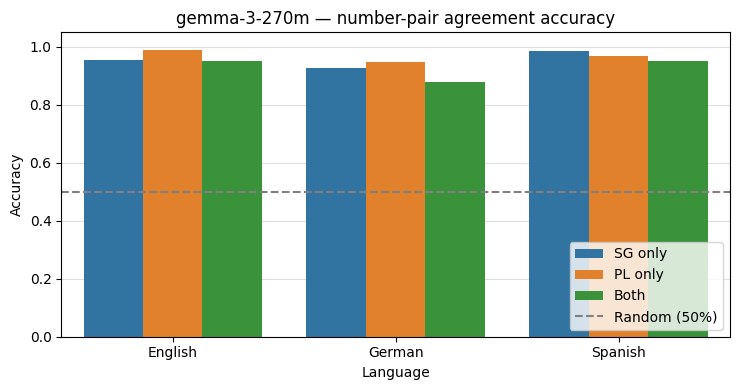

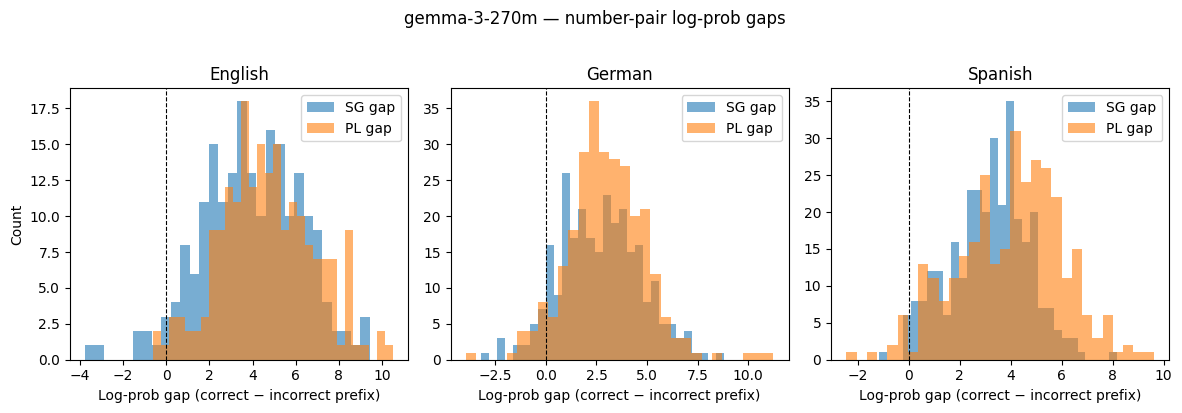

In [9]:
n_langs = len(np_summaries)
all_pairs = load_all_languages(filter_agreement=True, svo_only=True)
lang_names = {lc: next(l.name for l in cfg.languages if l.code == lc) for lc in list(all_pairs.keys())}

# --- Accuracy bar chart (SG / PL / Both) ---
rows = []
for lc, s in np_summaries.items():
    name = lang_names[lc]
    rows.append({"Language": name, "Metric": "SG only", "Accuracy": s["sg_accuracy"]})
    rows.append({"Language": name, "Metric": "PL only", "Accuracy": s["pl_accuracy"]})
    rows.append({"Language": name, "Metric": "Both", "Accuracy": s["both_accuracy"]})

acc_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(max(5, 2.5 * n_langs), 4))
sns.barplot(data=acc_df, x="Language", y="Accuracy", hue="Metric", ax=ax)
ax.axhline(0.5, ls="--", color="gray", label="Random (50%)")
ax.set_ylim(0, 1.05)
ax.set_title(f"{MODEL_KEY} — number-pair agreement accuracy")
ax.yaxis.grid(True, linestyle="-", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(loc="lower right")
plt.tight_layout()

out_dir = PROJECT_ROOT / "results" / "figures" / MODEL_KEY
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "competence_number_pairs.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Log-prob gap distributions (SG vs PL, faceted by language) ---
fig, axes = plt.subplots(1, n_langs, figsize=(4 * n_langs, 4), squeeze=False)
for i, (lc, results) in enumerate(np_results_by_lang.items()):
    ax = axes[0, i]
    sg_gaps = [r["sg_logprob_gap"] for r in results]
    pl_gaps = [r["pl_logprob_gap"] for r in results]
    ax.hist(sg_gaps, bins=30, alpha=0.6, label="SG gap")
    ax.hist(pl_gaps, bins=30, alpha=0.6, label="PL gap")
    ax.axvline(0, ls="--", color="black", lw=0.8)
    ax.set_title(lang_names[lc])
    ax.set_xlabel("Log-prob gap (correct − incorrect prefix)")
    ax.set_ylabel("Count" if i == 0 else "")
    ax.legend()
plt.suptitle(f"{MODEL_KEY} — number-pair log-prob gaps", y=1.02)
plt.tight_layout()
plt.savefig(out_dir / "competence_number_pairs_gaps.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
for lang_code, results in np_results_by_lang.items():
    errors = [r for r in results if not r["both_correct"]]
    print(f"\n{'='*70}")
    print(f" {lang_names[lang_code]} — {len(errors)} pair errors out of {len(results)}")
    print(f"{'='*70}")
    for r in errors[:8]:
        sg_mark = "OK" if r["sg_correct"] else "FAIL"
        pl_mark = "OK" if r["pl_correct"] else "FAIL"
        print(f"  {r['pair_id']}  SG[{sg_mark}] gap={r['sg_logprob_gap']:+.4f}  PL[{pl_mark}] gap={r['pl_logprob_gap']:+.4f}")
        print(f"    SG verb={r['sg_verb']!r}  PL verb={r['pl_verb']!r}")
        print(f"    SG prefix (good): {r['sg_good_prefix'][:70]}...")
        print()


 English — 10 pair errors out of 204
  eng_0052  SG[FAIL] gap=-0.1368  PL[OK] gap=+6.1436
    SG verb='preoccupies'  PL verb='preoccupy'
    SG prefix (good): As the hysteria of the 2016 Presidential election intensifies, a more ...

  eng_0053  SG[FAIL] gap=+0.0000  PL[OK] gap=+5.0000
    SG verb='demonstrates'  PL verb='demonstrate'
    SG prefix (good): And, a piece of shrapnel in the forearm that caused only a minor wound...

  eng_0070  SG[FAIL] gap=-3.7500  PL[OK] gap=+2.0000
    SG verb='crashes'  PL verb='crash'
    SG prefix (good): I really like the MIUI, but a process...

  eng_0195  SG[FAIL] gap=-0.5000  PL[OK] gap=+3.6875
    SG verb='understands'  PL verb='understand'
    SG prefix (good): A realist, and this even includes members of the U.S. Democratic forei...

  eng_0201  SG[OK] gap=+2.3906  PL[FAIL] gap=-0.5938
    SG verb='boxes.'  PL verb='box.'
    SG prefix (good): A member of the traveler community bare-knuckle...

  eng_0237  SG[FAIL] gap=-1.2500  PL[OK] gap=+5

### 2. Large-scale number-pair run (all models)

In [11]:
MODELS_TO_RUN = ['gemma-3-270m', 'gemma-3-1b', 'gemma-3-4b', 'gemma-3-12b']
MULTI_GPU = False
GPU_ID = 0

if torch.cuda.is_available():
    device_str = "auto" if MULTI_GPU else f"cuda:{GPU_ID}"

np_dfs = {}
for lang in cfg.languages:
    df = load_number_pairs(lang.code)
    if not df.empty:
        np_dfs[lang.code] = df

for model_key in MODELS_TO_RUN:
    model_cfg = cfg.models[model_key]
    print(f"\n{'#'*60}\n# Model: {model_key}\n{'#'*60}")
    model, tokenizer = load_model(model_cfg, device=device_str)
    device = next(model.parameters()).device

    np_results_by_lang = {}
    np_summaries = {}
    for lang_code, df in np_dfs.items():
        np_results = evaluate_all_number_pairs(model, tokenizer, df, device)
        np_results_by_lang[lang_code] = np_results
        np_summaries[lang_code] = summarize_number_pair_results(np_results)

    subdir = f"competence/{model_key}"
    save_results(
        {"model": model_key, "model_hf_id": model_cfg.hf_id, "summaries": np_summaries},
        filename="competence_number_pairs_summary",
        subdir=subdir,
    )
    for lang_code, np_res in np_results_by_lang.items():
        save_results(
            {"summary": np_summaries[lang_code], "pairs": np_res},
            filename=f"competence_number_pairs_{lang_code}",
            subdir=subdir,
        )

    print(f"{'Lang':<6} {'SG Acc':>8} {'PL Acc':>8} {'Both Acc':>10} {'N':>6}")
    for lc, s in np_summaries.items():
        print(f"{lc:<6} {s['sg_accuracy']:>8.3f} {s['pl_accuracy']:>8.3f} {s['both_accuracy']:>10.3f} {s['n']:>6d}")

    del model, tokenizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


############################################################
# Model: gemma-3-270m
############################################################
2026-04-19 13:27:12,924 | src.model.loading | INFO | Loading model google/gemma-3-270m ...


INFO:src.model.loading:Loading model google/gemma-3-270m ...


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

2026-04-19 13:27:17,154 | src.model.loading | INFO | Model loaded on cuda:0


INFO:src.model.loading:Model loaded on cuda:0
Evaluating number pairs: 100%|██████████| 313/313 [00:49<00:00,  6.27it/s]


...


INFO:src.model.loading:Loading model google/gemma-3-12b-pt ...


Loading weights:   0%|          | 0/1065 [00:00<?, ?it/s]

2026-04-19 13:36:44,316 | src.model.loading | INFO | Model loaded on cuda:0


INFO:src.model.loading:Model loaded on cuda:0
Evaluating number pairs: 100%|██████████| 313/313 [02:10<00:00,  2.41it/s]

Lang     SG Acc   PL Acc   Both Acc      N
eng       0.980    0.990      0.971    204
deu       0.964    0.985      0.953    274
spa       0.974    0.984      0.958    313


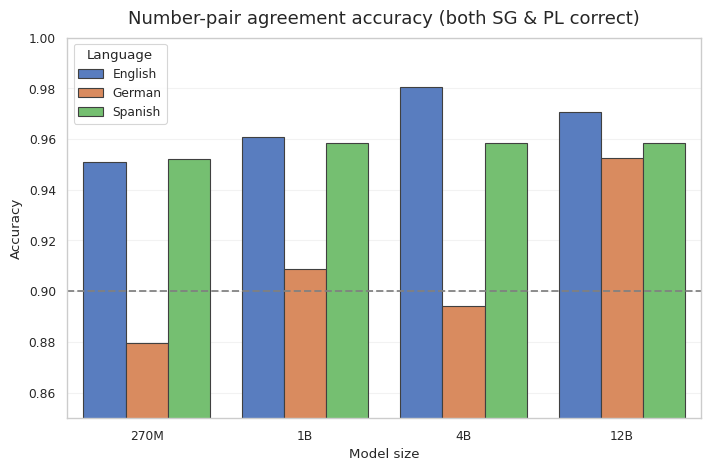

Saved: /content/multilingual-agreement/results/figures/competence_number_pairs_all_models_both_barplot.png


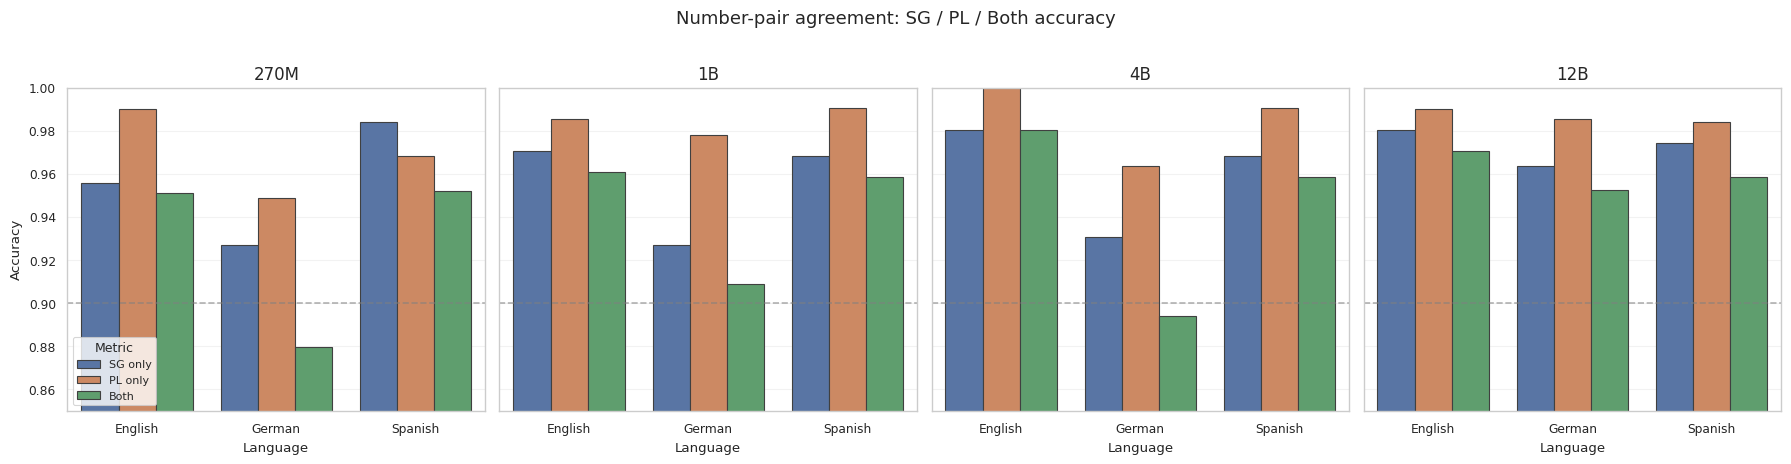

Saved: /content/multilingual-agreement/results/figures/competence_number_pairs_all_models_sg_pl_both.png


In [14]:
# Cross-model number-pair competence accuracy plots
import json
import re
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

competence_dir = PROJECT_ROOT / "results" / "competence"
out_dir = PROJECT_ROOT / "results" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

pat = re.compile(r"^competence_number_pairs_summary_(\d{8})_(\d{6})$")

rows = []
for p in sorted(competence_dir.glob("*/competence_number_pairs_summary_*.json")):
    m = pat.match(p.stem)
    if not m:
        continue
    timestamp = f"{m.group(1)}_{m.group(2)}"
    payload = json.loads(p.read_text())
    model = payload.get("model", p.parent.name)
    for lang, metrics in payload.get("summaries", {}).items():
        rows.append({
            "model": model,
            "language": lang,
            "sg_accuracy": metrics["sg_accuracy"],
            "pl_accuracy": metrics["pl_accuracy"],
            "both_accuracy": metrics["both_accuracy"],
            "n": metrics["n"],
            "timestamp": timestamp,
        })

np_df = pd.DataFrame(rows)
if np_df.empty:
    raise ValueError(f"No number-pair summary files found in {competence_dir}")

latest = (
    np_df.sort_values("timestamp")
    .groupby(["model", "language"], as_index=False)
    .tail(1)
    .copy()
)

model_order = ["gemma-3-270m", "gemma-3-1b", "gemma-3-4b", "gemma-3-12b"]
model_labels = {"gemma-3-270m": "270M", "gemma-3-1b": "1B", "gemma-3-4b": "4B", "gemma-3-12b": "12B"}
lang_order = ["eng", "deu", "spa"]
lang_names = {"eng": "English", "deu": "German", "spa": "Spanish"}
palette = ["#4878D0", "#EE854A", "#6ACC64"]

latest["model"] = pd.Categorical(latest["model"], categories=model_order, ordered=True)
latest["language"] = pd.Categorical(latest["language"], categories=lang_order, ordered=True)
latest = latest.sort_values(["model", "language"])
latest["Model size"] = latest["model"].map(model_labels)
latest["Language"] = latest["language"].map(lang_names)

sns.set_theme(style="whitegrid", context="paper")

# --- "Both correct" accuracy by model size ---
fig, ax = plt.subplots(figsize=(7.2, 4.8))
sns.barplot(
    data=latest, x="Model size", y="both_accuracy",
    hue="Language", hue_order=["English", "German", "Spanish"],
    ax=ax, edgecolor="0.25", linewidth=0.8, palette=palette,
)
ax.axhline(0.9, ls="--", lw=1.4, color="gray", alpha=0.9)
ax.set_title("Number-pair agreement accuracy (both SG & PL correct)", fontsize=13, pad=10)
ax.set_ylabel("Accuracy")
ax.set_ylim(0.85, 1.0)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
legend = ax.legend(title="Language", loc="upper left", frameon=True, fancybox=True, framealpha=0.8)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("0.8")
plt.tight_layout()
out_path = out_dir / "competence_number_pairs_all_models_both_barplot.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

# --- SG vs PL vs Both accuracy faceted by model size ---
plot_rows = []
for _, row in latest.iterrows():
    for metric, label in [("sg_accuracy", "SG only"), ("pl_accuracy", "PL only"), ("both_accuracy", "Both")]:
        plot_rows.append({
            "Model size": row["Model size"],
            "Language": row["Language"],
            "Metric": label,
            "Accuracy": row[metric],
        })
plot_df = pd.DataFrame(plot_rows)

fig, axes = plt.subplots(1, len(model_order), figsize=(4.5 * len(model_order), 4.5), sharey=True)
for i, (mkey, mlabel) in enumerate(model_labels.items()):
    ax = axes[i]
    sub = plot_df[plot_df["Model size"] == mlabel]
    sns.barplot(
        data=sub, x="Language", y="Accuracy", hue="Metric",
        hue_order=["SG only", "PL only", "Both"],
        ax=ax, edgecolor="0.25", linewidth=0.8,
    )
    ax.set_title(mlabel, fontsize=12)
    ax.set_ylim(0.85, 1.0)
    ax.axhline(0.9, ls="--", color="gray", alpha=0.6)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)
    if i > 0:
        ax.set_ylabel("")
        ax.legend().remove()
    else:
        ax.legend(title="Metric", loc="lower left", fontsize=8, title_fontsize=9)
plt.suptitle("Number-pair agreement: SG / PL / Both accuracy", fontsize=13, y=1.02)
plt.tight_layout()
out_path = out_dir / "competence_number_pairs_all_models_sg_pl_both.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")